<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK9_%ED%95%84%EC%82%AC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 5.3 전이 학습

전이 학습: 이미지넷처럼 아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 우리가 해결하려는 모델에 맞게 보정해서 사용하는 것.
- 아주 큰 데이터셋을 사용하여 훈련된 모델=사전훈련된 모델(네트워크)
- 특성 추출/미세 조정 기법

### 5.3.1 특성 추출 기법

특성 추출(feature extractor): 이미지넷 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만듦. 학습할 때는 마지막 완전연결층만 학습하고 나머지 계층은 학습되지 않도록 함.
- 합성곱층: 합성곱층과 풀링층으로 구성
- 데이터 분류기(완전연결층): 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스를 분류하는 부분

사전 훈련된 네트워크의 합성곱층(가중치 고정)에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기에서 훈련시킴.

사용 가능한 이미지 분류 모델: Xception, Inception V3, ResNet50, VGG16, VGG19, MobileNet

In [13]:
# 코드 5-12 라이브러리 호출
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# 코드 5-13 이미지 데이터 전처리 방법 정의
data_path='/content/drive/MyDrive/Colab/ESAA/catanddog/train'

transform=transforms.Compose(
    [
        transforms.Resize([256,256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)
train_dataset=torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)
train_loader=torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


1. torchvision.transform의 주요 파라미터
- Resize: 이미지 크기 조정
- RandomResizedCrop: 이미지 랜덤한 크기 및 비율로 자르기
- RandomHorizontalFlip: 이미지를 수평하게 뒤집음
- ToTensor: 이미지 데이터를 텐서로 변환

2. datasets.ImageFolder의 주요 파라미터
- transform: 이미지 데이터에 대한 전처리

**RandomResizedCrop 주요 파라미터**
- size: 출력할 크기 조정
- scale: 면적 비율을 0.1~1 범위 내에서 무작위로 자름
- ratio: 면적의 너비와 높이 비율을 0.5~2 범위 내에서 무작위로 조절

In [20]:
import numpy as np

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


AttributeError: module 'matplotlib.pyplot' has no attribute 'plt'

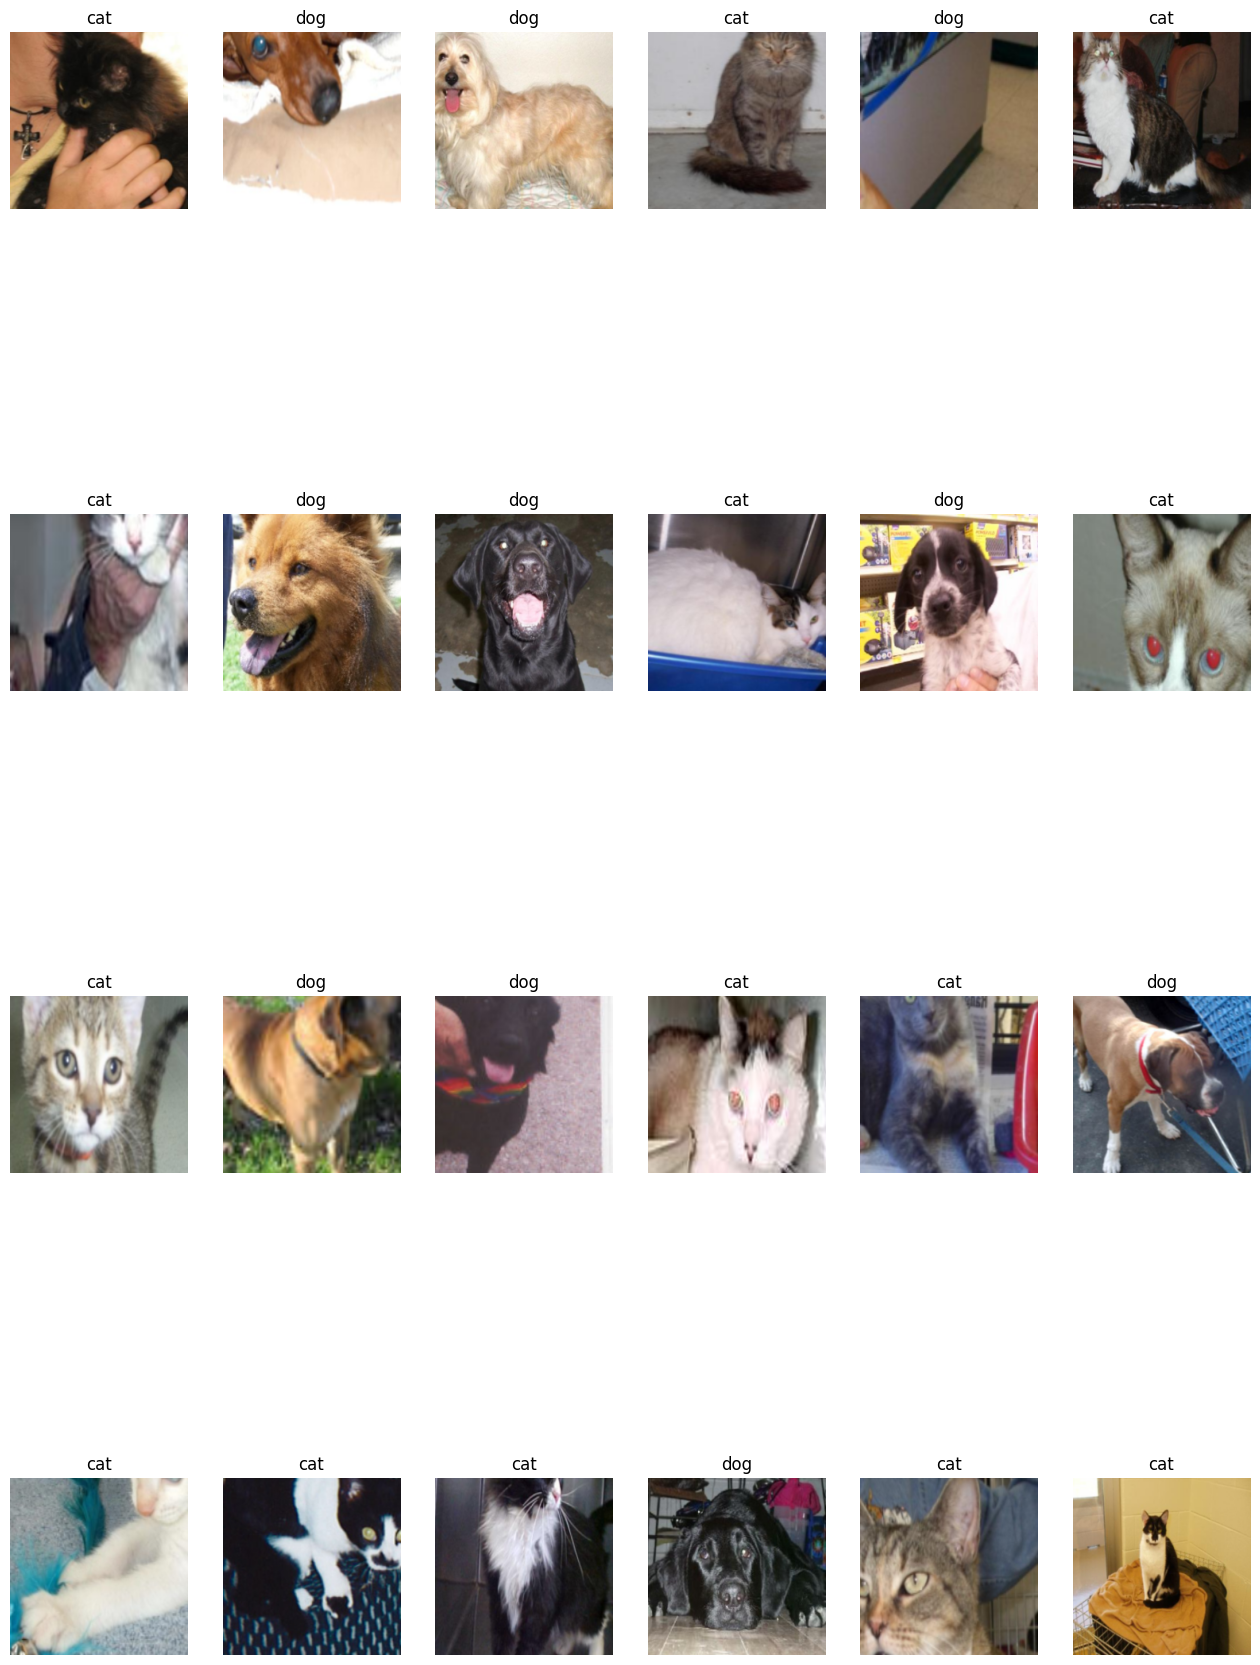

In [21]:
# 코드 5-14 학습에 사용될 이미지 출력
samples, labels = next(iter(train_loader))
classes={0:'cat',1:'dog'}
fig=plt.figure(figsize=(16,24))
for i in range(24):
  a=fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(),(1,2,0)))
plt.plt.subplots_adjust(bottom=0.2,top=0.6,hspace=0)

1. 반복자 사용: iter(전달된 데이터의 반복자를 꺼내 반환), next(반복자가 다음에 출력해야 할 요소를 반환)
2. np.transpose: 행과 열을 바꿈으로써 행렬의 차원을 바꾸어 줌

In [22]:
# 코드 5-15 사전 훈련된 모델 내려받기
resnet18=models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


**ResNet18**

50개의 계층으로 구성된 합성곱 신경망. ImageNet 데이터베이스의 100만 개가 넘는 영상을 이용하여 훈련된 신경망으로 전이 학습에 사용되도록 사전 훈련된 모델을 제공.
- 입력 제약이 매우 크고, 충분한 메모리가 없으면 학습 속도가 느릴 수 있음.

**사전 훈련된 모델**

In [23]:
# 코드 5-16 사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model,feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad=False

set_parameter_requires_grad(resnet18)

ResNet18의 마지막 부분에 완전연결층 추가 : 개와 고양이 클래스를 분류하는 용도로 사용.

In [24]:
# 코드 5-17 ResNet18에 완전연결층 추가
resnet18.fc=nn.Linear(512,2)

In [25]:
# 코드 5-18 모델의 파라미터 값 확인
for name,param in resnet18.named_parameters():
  if param.requires_grad:
    print(name,param.data)

fc.weight tensor([[-0.0353, -0.0369,  0.0070,  ...,  0.0168,  0.0082,  0.0318],
        [ 0.0420, -0.0121, -0.0406,  ..., -0.0141, -0.0165, -0.0172]])
fc.bias tensor([-0.0089,  0.0179])


In [26]:
# 코드 5-19 모델 객체 생성 및 손실 함수 정의
model=models.resnet18(pretrained=True)

for param in model.parameters():
  param.requires_grad=False

model.fc=torch.nn.Linear(512,2)
for param in model.fc.parameters():
  param.requires_grad=True

optimizer=torch.optim.Adam(model.fc.parameters())
cost=torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [34]:
def train_model(models,dataLoaders,criterion,optimizer,device,num_epochs=13,is_train=True):
  since=time.time()
  acc_history=[]
  loss_history=[]
  best_acc=0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch,num_epochs-1))
    print('-'*10)

    running_loss=0.0
    running_corrects=0

    for inputs,labels in dataLoaders:
      inputs=inputs.to(device)
      labels=labels.to(device)

      model.to(device)
      optimizer.zero_grad()
      outputs=model(inputs)
      loss=criterion(outputs,labels)
      _,preds=torch.max(outputs,1)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()*inputs.size(0)
      running_corrects += torch.sum(preds==labels.data)

    epoch_loss=running_loss/len(dataLoaders.dataset)
    epoch_acc=running_corrects.double()/len(dataLoaders.dataset)

    print('Loss:{:.4f} Acc:{:.4f}'.format(epoch_loss,epoch_acc))

    if epoch_acc>best_acc:
      best_acc=epoch_acc

    acc_history.append(epoch_acc)
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(),os.path.join('/content/drive/MyDrive/Colab/ESAA/catanddog/train','[0:0=2d].pth'.format(epoch)))
    print()

  time_elapsed=time.time()-since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,time_elapsed%60))
  print('Best Acc:{:4f}'.format(best_acc))
  return acc_history,loss_history

In [35]:
# 코드 5-21 파라미터 학습 결과를 옵티마이저에 전달
params_to_update=[]
for name,param in resnet18.named_parameters():
  if param.requires_grad==True:
    params_to_update.append(param)
    print("\t",name)

optimizer=optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [36]:
# 코드 5-22 모델 학습
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion=nn.CrossEntropyLoss()
train_acc_hist,train_loss_hist=train_model(resnet18,train_loader,criterion,optimizer,device)

Epoch 0/12
----------
Loss:0.8115 Acc:0.4104

Epoch 1/12
----------
Loss:0.8191 Acc:0.4260

Epoch 2/12
----------
Loss:0.8017 Acc:0.4364

Epoch 3/12
----------
Loss:0.8029 Acc:0.4338

Epoch 4/12
----------
Loss:0.8094 Acc:0.4312

Epoch 5/12
----------
Loss:0.7904 Acc:0.4545

Epoch 6/12
----------
Loss:0.7956 Acc:0.4338

Epoch 7/12
----------
Loss:0.7992 Acc:0.4078

Epoch 8/12
----------
Loss:0.8155 Acc:0.4052

Epoch 9/12
----------
Loss:0.8056 Acc:0.4260

Epoch 10/12
----------
Loss:0.8186 Acc:0.4182

Epoch 11/12
----------
Loss:0.8231 Acc:0.4234

Epoch 12/12
----------
Loss:0.8053 Acc:0.4416

Training complete in 0m 51s
Best Acc:0.454545


In [38]:
# 코드 5-23 테스트 데이터 호출 및 전처리
test_path='/content/drive/MyDrive/Colab/ESAA/catanddog/test'

transfrom=transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)
test_dataset=torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader=torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=0,
    shuffle=True
)

print(len(test_dataset))

98


In [40]:
# 코드 5-24 테스트 데이터 평가 함수 생성
def eval_model(model,dataloaders,device):
  since=time.time()
  acc_history=[]
  best_acc=0.0

  saved_models=glob.glob('/content/drive/MyDrive/Colab/ESAA/catanddog/'+'*.pth')
  saved_models.sort()
  print('saved_model',saved_models)

  for model_path in saved_models:
    print('Loading model',model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects=0

    for inputs,labels in dataloaders:
      inputs=inputs.to(device)
      labels=labels.to(device)

      with torch.no_grad():
        outputs=model(inputs)

      _,preds=torch.max(outputs.data,1)
      preds[preds>=0.5]=1
      preds[preds<0.5]=0
      running_corrects += preds.eq(labels.cpu()).int().sum()

    epoch_acc=running_corrects.double()/len(dataloaders.dataset)
    print('Acc:{:4f}'.format(epoch_acc))

    if epoch_acc>best_acc:
      best_acc=epoch_acc
      acc_history.append(epoch_acc.item())
      print()

    time_elapsed=time.time()-since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,time_elapsed%60))
    print('Best Acc:{:4f}'.format(best_acc))

    return acc_history

3. preds.eq(labels): preds 배열과 labels가 일치하는지 검사하는 용도

In [41]:
# 코드 5-25 테스트 데이터를 평가 함수에 적용
val_acc_hist=eval_model(resnet18,test_loader,device)

saved_model []


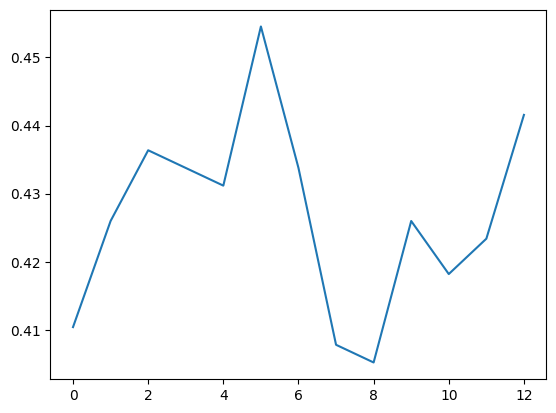

In [47]:
# 코드 5-26 훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot([x.cpu().item() for x in train_acc_hist])
if val_acc_hist is not None:
    plt.plot([x.cpu().item() for x in val_acc_hist])
plt.show()

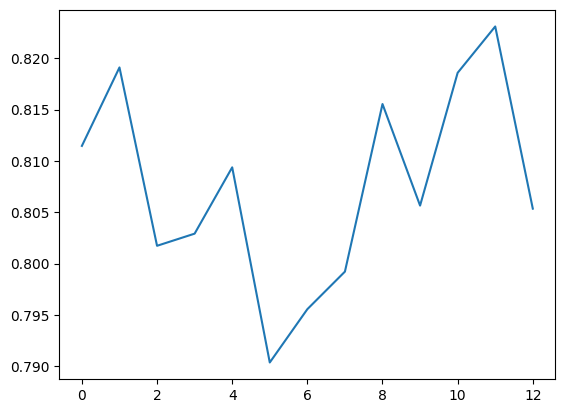

In [48]:
# 코드 5-27 훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

In [53]:
# 코드 5-28 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image=tensor.clone().detach().cpu().numpy()
  image=image.transpose(1,2,0)
  image=image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
  image=image.clip(0,1)
  return image

tensor.clone(): 메모리 새롭게 할당, 계산 그래프에 계속 상주

tensor.detach(): 메모리 공유해서 사용. 계산 그래프에 상주하지 않음

tensor.clone().detach(): 메모리 새롭게 할당. 계산 그래프에 상주하지 않음

**계산 그래프**: 국소적 계산이 가능, 역전파를 통한 미분 계산 편리

**연쇄 법칙**: 두 개 이상의 함수가 결합된 함수, 즉 합성 함수의 연쇄 법칙 혹은 체인룰이라 함.

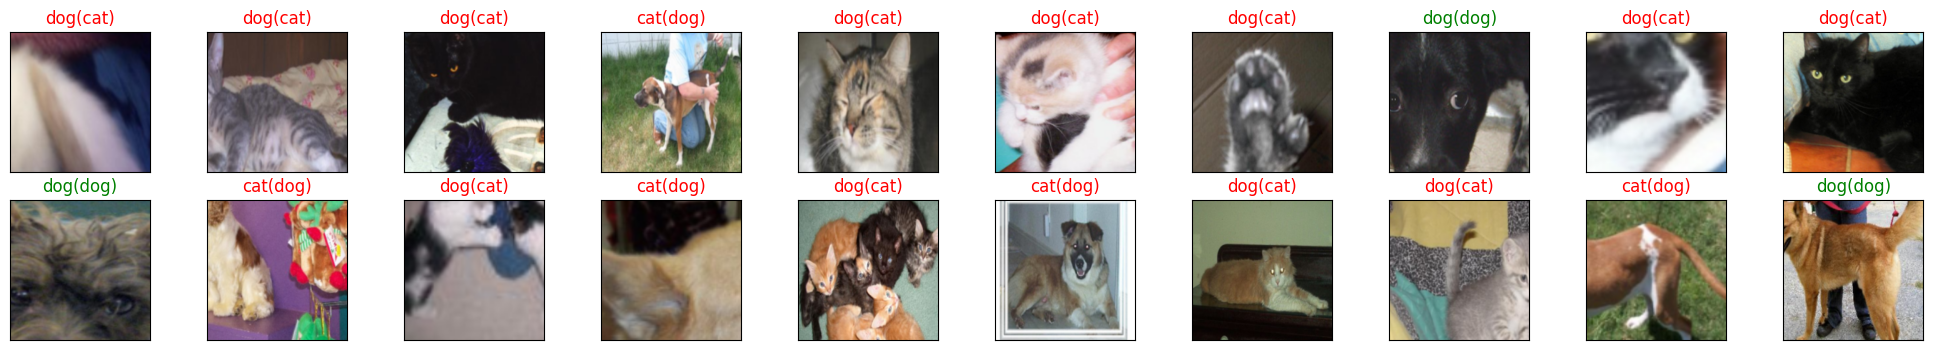

<Figure size 640x480 with 0 Axes>

In [54]:
# 코드 5-29 개와 고양이 예측 결과 출력
classes={0:'cat',1:'dog'}

detaiter=iter(test_loader)
images,labels=next(detaiter)
images = images.to(device)
output=model(images)
_,preds=torch.max(output,1)

fig=plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax=fig.add_subplot(2,10,idx+1,xticks=[],yticks=[])
  plt.imshow(im_convert(images[idx]))
  ax.set_title(classes[labels[idx].item()])
  ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].item()])),color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2,top=0.6,hspace=0)

### 5.3.2 미세 조정 기법

미세 조정 기법(fine-tuning): 특성 추출 기법에서 더 나아가 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이트하여 훈련시키는 방식
- 특성 추출이 잘못되었다면 미세 조정 기법으로 새로운 이미지 데이터를 사용하여 네트워크의 가중치를 업데이트해서 특성을 다시 추출할 수 있음. 사전 훈련된 네트워크를 미세 조정하여 분석하려는 데이터셋에 잘 맞도록 모델의 파라미터를 조정하는 기법.
   - 데이터셋이 크고 사전 훈련된 모델과 유사성이 작을 경우: 모델 전체 재학습
   - 데이터셋이 크고 사전 훈련된 모델과 유사성이 클 경우: 합성곱층의 뒷부분과 데이터 분류기 학습
   - 데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우: 합성곱층의 일부분과 데이터 분류기 학습
   - 데이터셋이 작고 사전 훈련된 모델과 유사성이 클 경우: 데이터 분류기만 학습